### **House Price Prediction**

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

**Load Dataset**

**Loading the Dataset**

The House Price data is loaded and examined to gain insight into the house related features like area, bedroom, bathroom, parking and furnishing status.

The target variable is the house price.

In [ ]:
df = pd.read_csv("/content/Housing.csv")

**Basic Information**

**Data Preprocessing**

Data preprocessing includes:

- Handling missing values
- Encoding categorical variables
- Training a numerical model to detect frauds.- Generating training data for a numerical model to identify frauds.

The following steps make sure that the data is appropriate for machine learning algorithms.

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    o

**Summary Statistics**

In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Missing Values**

In [ ]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


**Handle Missing Values**

In [ ]:
df = df.dropna()
print("New Shape:", df.shape)

New Shape: (545, 13)


**House Price Distribution**

**Exploratory Data Analysis**

The effect of the property features on house prices is explained by using visualizations.

The analysis is based on the following:
The relationship between area and price.The area-price relationship.
- Distribution of house prices
- Correlations between features

This helps to determine what factors are most significant in the value of the property.

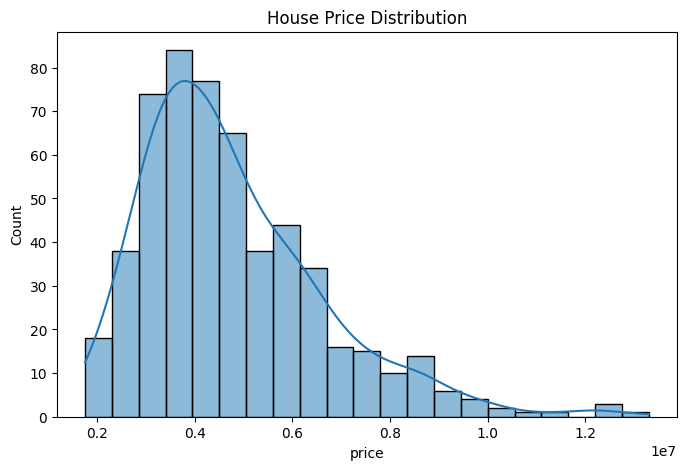

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)

plt.title("House Price Distribution")
plt.show()

**Correlation Heatmap**

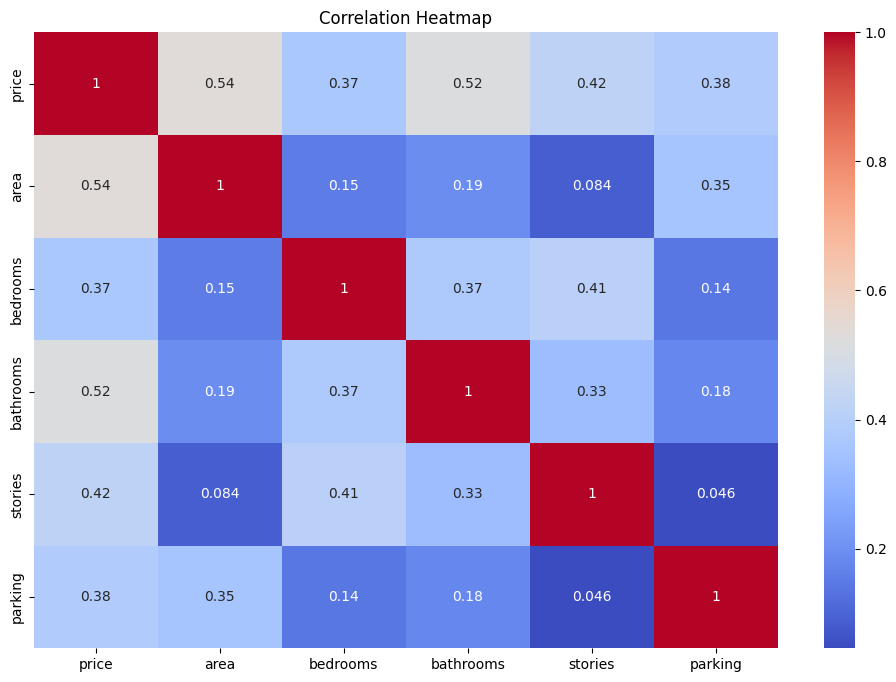

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

**Price vs Area**

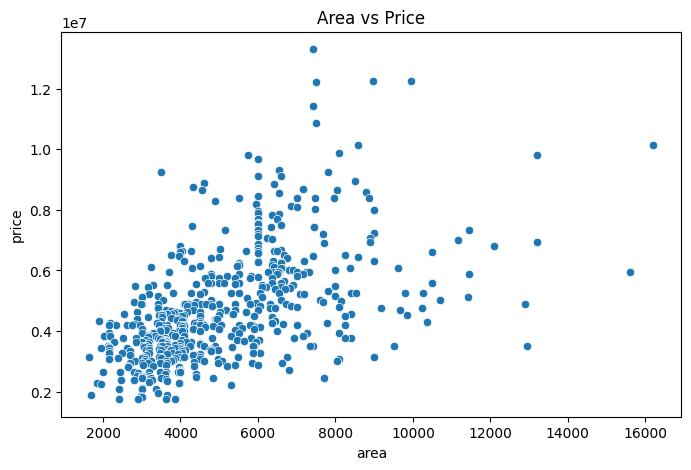

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='area',
    y='price',
    data=df
)

plt.title("Area vs Price")
plt.show()

**Encode Categorical Columns**

In [ ]:
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label_encoder.fit_transform(df[col])

**Features and Target**

**Feature Selection**

Property characteristics such as:

- Area
- Bedrooms
- Bathrooms
- Stories
- Parking
- Air Conditioning
- Furnishing Status

are used as input features for predicting house prices.
This process is repeated until the model has been trained.The model is trained until it is done.

Linear Regression is employed to learn a property characteristic to house price relation.

The model forecasts house prices as a function of the selected property features.

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

**Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

**Train Linear Regression**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training is done.")

Model training is done.


**Predictions**

In [ ]:
y_pred = model.predict(X_test)

**Evaluation Metrics**

**Model Evaluation**

The model is evaluated using:

Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These are indicators of the accuracy of price forecasts.

**Results and Discussion**

The Linear Regression model was able to learn the relationship between house characteristics and house price successfully.

Evaluation Results:

- MAE = 979,680
- RMSE = 1,331,071
- R² Score = 0.649

The model accounts for about 65% of the variance in house prices.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 979679.6912959907
RMSE: 1331071.4167895124
R² Score: 0.6494754192267793


**Actual vs Predicted Plot**

The Actual vs Predicted plot demonstrates a positive correlation between the predicted value and the actual value, suggesting that the model generally performs well in predicting the prices.

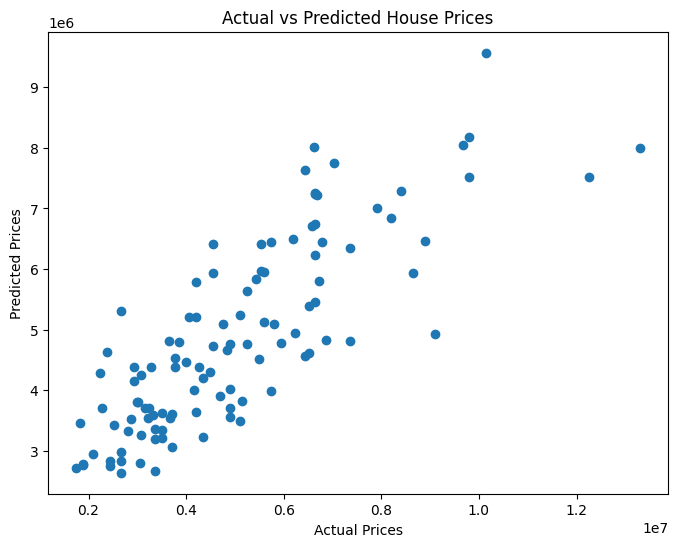

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

**Feature Importance**

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance

,Feature,Coefficient
2,bathrooms,550762.108735
0,area,511355.314864
8,airconditioning,365086.933939
3,stories,352072.086344
10,prefarea,267023.364350
9,parking,194330.065331
6,basement,187581.884388
7,hotwaterheating,143909.241493
4,mainroad,127770.253636
5,guestroom,89178.007942


**Feature Importance Plot**

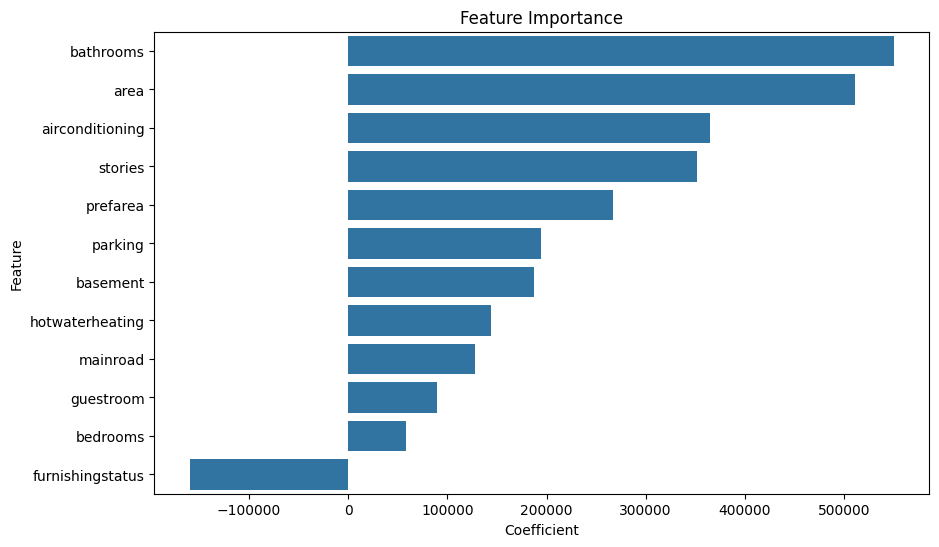

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

**Final Insights**

The feature importance analysis showed the following features were most important in determining house prices:

- Bathrooms
- Area
- Air Conditioning
- Stories
- Preferred Area (prefarea)

The most positive effect on property value was from these features.

The model offers good approximation of prices and shows the potential use of machine learning in real estate valuation.

The future enhancements that could be made include:

- Random Forest Regression
- Gradient Boosting
- XGBoost
- Additional location-based features
- Larger housing datasets